In [1]:
#prueba inicial
import pandas as pd
import numpy as np
import src.analytics as ana

precios = pd.Series([25, 40,54, 67])

logs = ana.log_returns(precios)
logs

1    0.470004
2    0.300105
3    0.215709
dtype: float64

In [2]:
import src.contracts as ct 
ct.Params.cost_buy

0.0

In [3]:
ct.Window("2024-12-02", "2025-01-15", "y", 6)

Window(start='2024-12-02', end='2025-01-15', freq='y', m=6, H=5)

In [4]:
ct.Params.confidence

0.95

In [5]:
import src.forecasting as fc
import matplotlib.pyplot as plt

fx = pd.read_csv("notebooks/Fixture_20_activos_sintetico_TBS_EIA.csv", parse_dates=["date"])

precios_aapl = fx[fx.ticker == "AAPL"].sort_values("date").set_index("date")["adjusted_close"]
g = ana.log_returns(precios_aapl)
P_t = precios_aapl.iloc[-1] 
params = ct.Params()

print(len(precios_aapl), "precios ->", len(g), "rendimientos.  P_t =", round(P_t, 4)) 

540 precios -> 539 rendimientos.  P_t = 73.6334


In [6]:
for modelo in ("A", "B"):
    mu, sigma = fc.fit(g, modelo)
    print(f"modelo {modelo}:  mu = {mu:.12f}   sigma = {sigma:.12f}")

modelo A:  mu = 0.000000000000   sigma = 0.004169173960
modelo B:  mu = 0.000093883279   sigma = 0.004169173960


In [7]:
mu, sigma = fc.fit(g, "B")

pd.DataFrame([
    {"h": h, "m": m, "v": v, "sd": np.sqrt(v), "sd/sd(h=1)": np.sqrt(v) / sigma}
    for h in (1, 4, 9, 16, 20)
    for m, v in [fc.cumulative_moments(mu, sigma, h)]
])

,h,m,v,sd,sd/sd(h=1)
0,1,0.000094,0.000017,0.004169,1.000000
1,4,0.000376,0.000070,0.008338,2.000000
2,9,0.000845,0.000156,0.012508,3.000000
3,16,0.001502,0.000278,0.016677,4.000000
4,20,0.001878,0.000348,0.018645,4.472136


In [8]:
m, v = fc.cumulative_moments(mu, sigma, 20)
fc.terminal(P_t, m, v, params)

{'median': np.float64(73.77175945267831),
 'mean': np.float64(73.78458358290783),
 'q_L': np.float64(71.54363288900151),
 'q_U': np.float64(76.06927790747508)}

In [9]:
tabla = fc.path(P_t, mu, sigma, 20, params)
tabla["ancho_%"] = (tabla.q_U - tabla.q_L) / P_t * 100
tabla

,h,median,mean,q_L,q_U,ancho_%
0,1,73.640284,73.640924,73.137010,74.147021,1.371676
1,2,73.647198,73.648478,72.936403,74.364920,1.940040
2,3,73.654112,73.656033,72.784435,74.534181,2.376295
3,4,73.661028,73.663588,72.657637,74.678275,2.744189
4,5,73.667944,73.671145,72.546919,74.806291,3.068408
5,6,73.674860,73.678702,72.447619,74.922890,3.361615
6,7,73.681777,73.686260,72.356971,75.030840,3.631328
7,8,73.688695,73.693819,72.273168,75.131946,3.882448
8,9,73.695613,73.701378,72.194960,75.227460,4.118377
9,10,73.702533,73.708938,72.121433,75.318294,4.341592


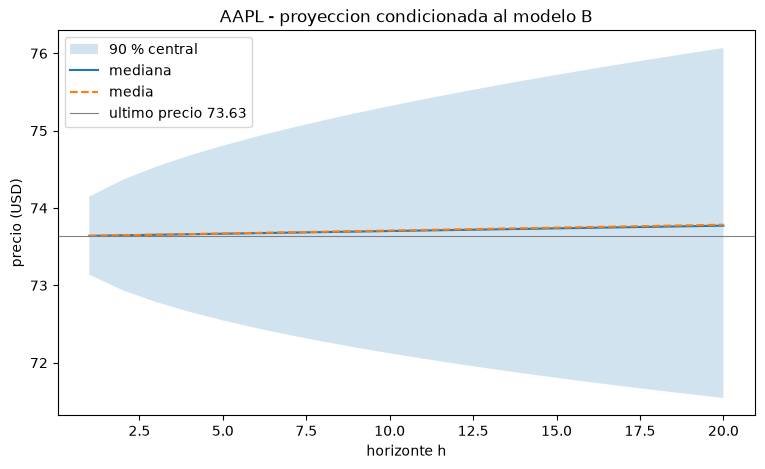

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(tabla.h, tabla.q_L, tabla.q_U, alpha=0.2, label="90 % central")
ax.plot(tabla.h, tabla["median"], label="mediana")
ax.plot(tabla.h, tabla["mean"], linestyle="--", label="media")
ax.axhline(P_t, color="gray", linewidth=0.8, label=f"ultimo precio {P_t:.2f}")
ax.set_xlabel("horizonte h")
ax.set_ylabel("precio (USD)")
ax.set_title("AAPL - proyeccion condicionada al modelo B")
ax.legend()
plt.show()

In [11]:
for modelo in ("A", "B"):
    r = fc.walk_forward(g, modelo, 20, 252, params)
    print(f"--- modelo {modelo} ---")
    print(f"   origenes   {r['origins'][0]} .. {r['origins'][-1]}")
    print(f"   MAE        {r['mae']:.12f}")
    print(f"   RMSE       {r['rmse']:.12f}")
    print(f"   cobertura  {r['coverage']:.2f}   (prometia 0.90)")
    print(f"   direccion  {r['direction']}   sobre {r['direction_n']} origenes")

--- modelo A ---
   origenes   510 .. 519
   MAE        0.047838991594
   RMSE       0.049889389325
   cobertura  0.20   (prometia 0.90)
   direccion  None   sobre 0 origenes
--- modelo B ---
   origenes   510 .. 519
   MAE        0.050673668010
   RMSE       0.052630163460
   cobertura  0.10   (prometia 0.90)
   direccion  0.0   sobre 10 origenes
